In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('UNSW_NB15_training-set.csv')

# Display the first few rows of the dataset to inspect it
df.head()


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [2]:
from sklearn.preprocessing import MinMaxScaler

# Drop rows with missing values
df = df.dropna()

# One-hot encode categorical variables (if any)
df = pd.get_dummies(df)

# Separate features (X) and target variable (y)
X = df.drop('label', axis=1)  # Replace 'label' with the actual column name of the target variable
y = df['label']  # Replace with the actual target column name

# Normalize the features using MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets (80% training, 20% testing)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Check the shapes of the data after splitting
print(X_train.shape, X_test.shape)


(65865, 201) (16467, 201)


In [3]:
import numpy as np

# Reshape the data to create a "1D image" (samples, features, 1, 1)
X_train_reshaped = np.expand_dims(X_train, axis=-1)  # Shape: (samples, 201, 1, 1)
X_test_reshaped = np.expand_dims(X_test, axis=-1)  # Shape: (samples, 201, 1, 1)

# Check the new shape of the data
print(X_train_reshaped.shape)


(65865, 201, 1)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Define the CNN model architecture
model = Sequential()

# First convolutional layer with padding and smaller pool size
model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(201, 1, 1)))  # Input shape adjusted
model.add(MaxPooling2D(pool_size=(2, 1)))  # Reduced pooling to avoid excessive downsampling

# Second convolutional layer with padding and smaller pool size
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 1)))  # Reduced pooling

# Flatten the output from convolutional layers
model.add(Flatten())

# Fully connected layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))  # Dropout for regularization

# Output layer (use softmax for multi-class classification)
model.add(Dense(len(y.unique()), activation='softmax'))  # Adjust the output layer size according to the number of classes

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

# Display model summary
model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_1 (Conv2D)           (None, 201, 1, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 100, 1, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 100, 1, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 50, 1, 64)        0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 3200)              0         
                                                                 
 dense (Dense)               (None, 128)              

In [6]:
# Train the model
history = model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_data=(X_test_reshaped, y_test))


Epoch 1/10
2059/2059 [==============================] - 32s 15ms/step - loss: 0.0096 - accuracy: 0.9966 - val_loss: 8.0439e-07 - val_accuracy: 1.0000
Epoch 2/10
2059/2059 [==============================] - 37s 18ms/step - loss: 5.0873e-06 - accuracy: 1.0000 - val_loss: 3.9606e-08 - val_accuracy: 1.0000
Epoch 3/10
2059/2059 [==============================] - 38s 19ms/step - loss: 1.1909e-06 - accuracy: 1.0000 - val_loss: 6.7108e-09 - val_accuracy: 1.0000
Epoch 4/10
2059/2059 [==============================] - 40s 19ms/step - loss: 2.9755e-07 - accuracy: 1.0000 - val_loss: 4.4884e-10 - val_accuracy: 1.0000
Epoch 5/10
2059/2059 [==============================] - 39s 19ms/step - loss: 1.6349e-07 - accuracy: 1.0000 - val_loss: 4.4884e-10 - val_accuracy: 1.0000
Epoch 6/10
2059/2059 [==============================] - 41s 20ms/step - loss: 5.2062e-08 - accuracy: 1.0000 - val_loss: 5.7914e-11 - val_accuracy: 1.0000
Epoch 7/10
2059/2059 [==============================] - 40s 20ms/step - loss: 6.

In [7]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test_reshaped, y_test)
print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_accuracy}')


515/515 [==============================] - 2s 4ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Test Loss: 0.0
Test Accuracy: 1.0


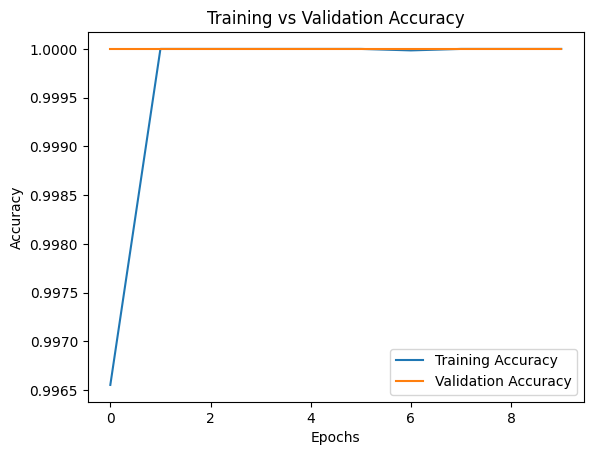

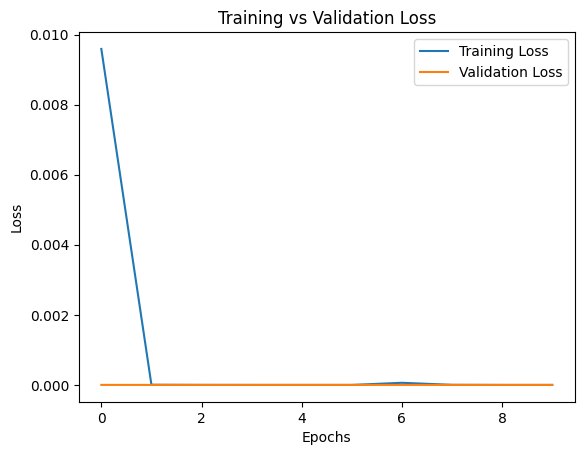

In [8]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training & validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


515/515 [==============================] - 2s 4ms/step


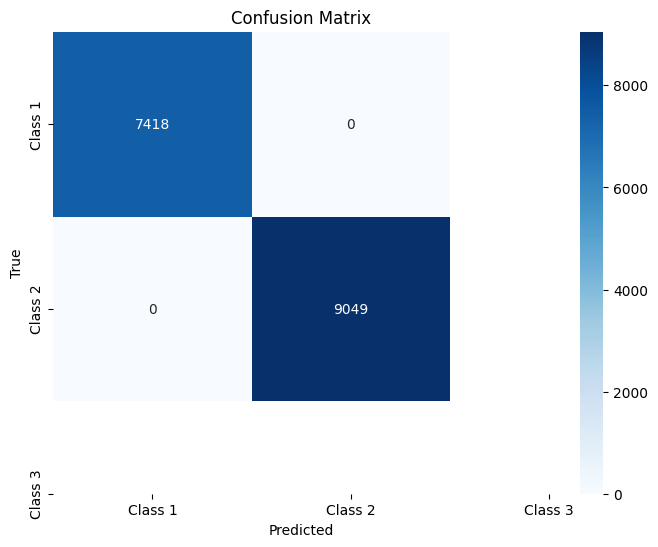

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predict labels on test data
y_pred = model.predict(X_test_reshaped)
y_pred = np.argmax(y_pred, axis=1)

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 1', 'Class 2', 'Class 3'], yticklabels=['Class 1', 'Class 2', 'Class 3'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
